## 1. Variables

- $T_{n,j}$: viable tumor
- $D_{n,j}$: doomed tumor
- $L_{n,j}$: active lymphocytes/CTLs
- $A_{n,j}$: immune-triggering-cell density
- $Z_n^p$: primary immune effect
- $Z_n^s$: secondary immune effect
- $\varepsilon_n$: radiation-induced activation fraction


$$
V_n(t)=\sum_{j=1}^{M}\left[T_{n,j}(t)+D_{n,j}(t)\right].
\tag{1}
$$

In [1]:
import sys
from pathlib import Path
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

src_root = Path.cwd().resolve() / "src"
if not (src_root / "radioim").exists():
    raise RuntimeError(f"Could not locate the radioim package under {src_root}")
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


from radioim import (
    DEFAULT_VOLUME_FIT_SPECS,
    STANDARD_THREE_ARMS,
    ModelParameters,
    log_bounds,
    generate_synthetic_dataset,
    simulate,
    clearance_weights,
    build_dose_schedule,
    survival_fractions,
    chi_square,
    residual_vector,
    fit_dataset,
    parameter_recovery_table
)


ARM_COLORS = {
    "No radiation": "tab:blue",
    "10 Gy, 50%": "0.50",
    "10 Gy, 100%": "black",
}


In [2]:
TRUE_PARAMS = ModelParameters(
    n_days=61,
    n_bins=2,
)

pd.DataFrame(
    {
        "parameter": asdict(TRUE_PARAMS).keys(),
        "value": asdict(TRUE_PARAMS).values(),
    }
)

,parameter,value
0,alpha_t,0.050000
1,beta_t,0.011364
2,alpha_l,0.182000
3,beta_l,0.143000
4,mu,0.216608
5,lambda_t,0.045158
6,lambda_a,0.045158
7,lambda_l,0.045158
8,rho,0.500000
9,psi,300.000000


In [3]:
dose_50 = build_dose_schedule(TRUE_PARAMS, coverage=0.5)
dose_100 = build_dose_schedule(TRUE_PARAMS, coverage=1.0)

assert np.count_nonzero(dose_50[TRUE_PARAMS.treatment_day]) == 1
assert np.count_nonzero(dose_100[TRUE_PARAMS.treatment_day]) == 2

pd.DataFrame(
    {
        "coverage": [0.5, 1.0],
        "irradiated_bins": [
            np.count_nonzero(dose_50[TRUE_PARAMS.treatment_day]),
            np.count_nonzero(dose_100[TRUE_PARAMS.treatment_day]),
        ],
        "dose_gy": [dose_50.max(), dose_100.max()],
    }
)


,coverage,irradiated_bins,dose_gy
0,0.5,1,10.0
1,1.0,2,10.0


In [4]:
weights = clearance_weights(TRUE_PARAMS)
sn_t_100, sn_l_100 = survival_fractions(dose_100, TRUE_PARAMS)

In [5]:
weights[:5]

array([0.04471385, 0.10934005, 0.21296534, 0.26596152, 0.21296534])

In [6]:
sn_t_100[10:15]

array([[0.92944456, 0.92944456],
       [0.83617272, 0.83617272],
       [0.70575387, 0.70575387],
       [0.64712891, 0.64712891],
       [0.70575387, 0.70575387]])

## Fitting parameters

$$
\boxed{\theta=(\mu,\omega,\psi,\kappa)}
$$
- $\mu$: tumor growth rate
- $\omega$: CTL-to-killing efficiency
- $\psi$: radiation-induced infiltration/activation
- $\kappa$: immune suppression


Fixed parameters

$$
\rho,\;
\alpha_T,\beta_T,\alpha_L,\beta_L,\;
\lambda_T,\lambda_L,\lambda_A,\;
\gamma,r,s,\;
d_{\mathrm{RT}},t_{\mathrm{RT}}.
$$

In [7]:
ARMS = STANDARD_THREE_ARMS
ARM_COLORS = {
    "No radiation": "tab:blue",
    "10 Gy, 50%": "0.50",
    "10 Gy, 100%": "black",
}

true_results = {
    arm.name: simulate(TRUE_PARAMS, arm.coverage)
    for arm in ARMS
}

relative_days = (
    np.arange(TRUE_PARAMS.n_days)
    - TRUE_PARAMS.treatment_day
)


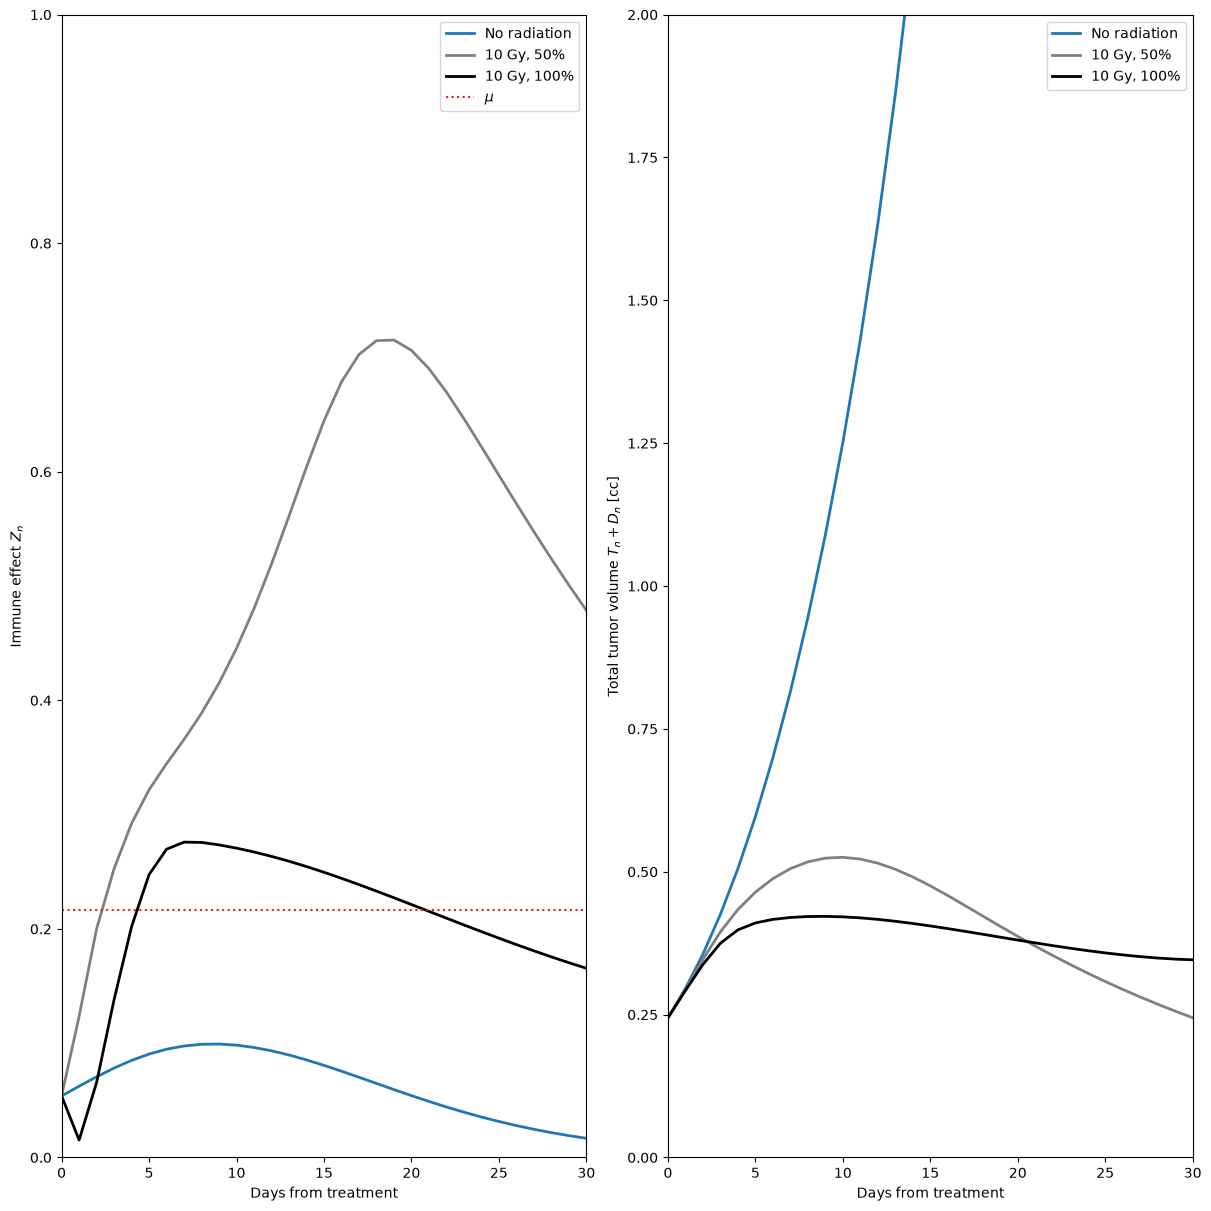

In [8]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 12),
    constrained_layout=True,
)
for arm in STANDARD_THREE_ARMS:
    result = true_results[arm.name]
    color = ARM_COLORS[arm.name]
    axes[0].plot(
        relative_days,
        result.immune_effect,
        color=color,
        linewidth=2,
        label=arm.name,
    )
    axes[1].plot(
        relative_days,
        result.total_volume,
        color=color,
        linewidth=2,
        label=arm.name,
    )

axes[0].axhline(
    TRUE_PARAMS.mu,
    color="tab:red",
    linestyle=":",
    linewidth=1.5,
    label=r"$\mu$",
)
axes[0].set(
    xlim=(0, 30),
    ylim=(0, 1),
    xlabel="Days from treatment",
    ylabel=r"Immune effect $Z_n$",
)
axes[1].set(
    xlim=(0, 30),
    ylim=(0, 2),
    xlabel="Days from treatment",
    ylabel=r"Total tumor volume $T_n+D_n$ [cc]",
)
axes[0].legend()
axes[1].legend()


## 6. Synthetic multiplicative noise

V>0, log-normal noise

$$
\log V_{a,i}^{\mathrm{obs}}
=
\log V_{a,i}^{\mathrm{true}}
+
\eta_{a,i},
\qquad
\eta_{a,i}\sim\mathcal N(0,\sigma_{\log V}^2).
\tag{20}
$$


$$
V_{a,i}^{\mathrm{obs}}
=
V_{a,i}^{\mathrm{true}}
\exp(\eta_{a,i}).
\tag{21}
$$


$$
\sigma_{\log V}=0.1
$$

10% multiplicative scatter


In [9]:
OBSERVATION_DAYS = np.arange(0, 31, 1)
DATASET = generate_synthetic_dataset(
    TRUE_PARAMS,
    relative_days=OBSERVATION_DAYS,
    log_sigma=0.1,
    seed=0,
    arms=ARMS,
)

pd.DataFrame(
    [
        {
            "arm": arm.name,
            "coverage": arm.coverage,
            "dose_gy": arm.dose_gy,
            "treatment_day": arm.treatment_day,
            "n_points": len(arm.relative_days),
            "first_day": arm.relative_days.min(),
            "last_day": arm.relative_days.max(),
            "log_sigma": np.asarray(arm.log_sigma).mean(),
        }
        for arm in DATASET.arms
    ]
)


,arm,coverage,dose_gy,treatment_day,n_points,first_day,last_day,log_sigma
0,No radiation,0.0,0.0,10,31,0,30,0.1
1,"10 Gy, 50%",0.5,10.0,10,31,0,30,0.1
2,"10 Gy, 100%",1.0,10.0,10,31,0,30,0.1


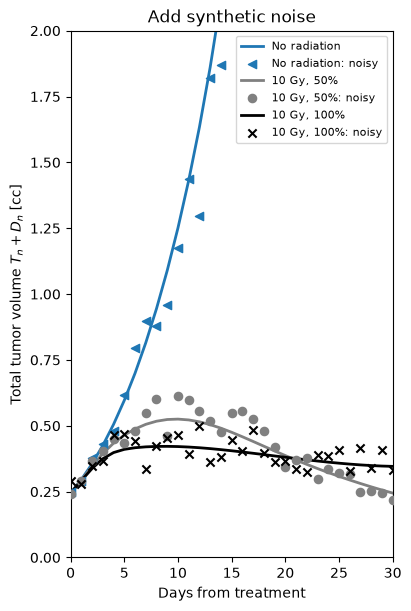

In [10]:
ARM_MARKERS = {
    "No radiation": "<",
    "10 Gy, 50%": "o",
    "10 Gy, 100%": "x",
}

fig, ax = plt.subplots(1,1,figsize=(4, 6), constrained_layout=True,)

for arm in DATASET.arms:
    color = ARM_COLORS[arm.name]
    marker = ARM_MARKERS[arm.name]

    ax.plot(
        arm.relative_days,
        arm.clean_volume,
        color=color,
        linewidth=2,
        label=arm.name,
    )
    ax.scatter(
        arm.relative_days,
        arm.observed_volume,
        color=color,
        marker=marker,
        # facecolors='none',
        s=35,
        label=f"{arm.name}: noisy",
        zorder=3
    )

ax.set(
    xlim=(0, 30),
    ylim=(0, 2),
    xlabel="Days from treatment",
    ylabel=r"Total tumor volume $T_n+D_n$ [cc]",
    title="Add synthetic noise",
)
ax.legend(fontsize=8, ncol=1)

## 왜 $\rho$는 고정?

방사선이 없고 immune suppression이 아직 작을 때

$$
L_{n+1}\approx(1-\lambda_L)L_n+\rho T_{n+1},
\qquad
Z_n^p\approx\omega L_n.

$$

따라서 no-radiation volume은 주로

$$
g_0=\omega\rho

$$

에 민감합니다.

조사 후에는

$$
L_{n+1}^{RT}
\supset
\psi\varepsilon_{n+1}A_{n+1}T_{n+1},

$$

이므로 radiation-induced immune effect는 주로

$$
g_{RT}=\omega\psi

$$

에 민감합니다.

즉 volume-only 데이터에서 $\rho,\omega,\psi$를 모두 풀면 강한 parameter ridge가 생깁니다. 여기서는 논문값

$$
\rho=0.5
$$

를 고정하고 $\omega,\psi$를 fitting


## Log-parameter optimization

파라미터의 단위와 크기가 크게 다릅니다.

$$
\mu\sim10^{-1},\quad
\omega\sim10^{-1},\quad
\psi\sim10^2,\quad
\kappa\sim10^0
$$

따라서 optimizer는 자연 파라미터 대신

$$
u_j=\log\theta_j
\tag{26}
$$

를 탐색합니다. 이 방식은 positivity를 자동으로 보장하고, additive step이 상대적 변화로 해석


In [11]:
FIT_SPECS = DEFAULT_VOLUME_FIT_SPECS
LOG_BOUNDS = log_bounds(FIT_SPECS)

pd.DataFrame(
    {
        "parameter": [spec.name for spec in FIT_SPECS],
        "lower": [spec.lower for spec in FIT_SPECS],
        "true": [
            getattr(TRUE_PARAMS, spec.name)
            for spec in FIT_SPECS
        ],
        "upper": [spec.upper for spec in FIT_SPECS],
    }
)


,parameter,lower,true,upper
0,mu,0.023105,0.216608,0.462098
1,omega,0.010000,0.135000,0.300000
2,psi,10.000000,300.000000,800.000000
3,kappa,0.050000,1.100000,2.500000


## Residual과 목적함수

Arm $a$, 관측점 $i$의 standardized log residual은

$$
r_{a,i}(\theta)
=
\frac{
\log V_a^{pred}(t_i;\theta)
-
\log V_{a,i}^{obs}
}{
\sigma_{\log V,a}
}
$$

모든 arm의 residual을 하나의 벡터로 연결

$$
\mathbf r(\theta)
=
\begin{bmatrix}
\mathbf r_{\mathrm{noRT}}\\
\mathbf r_{50\%}\\
\mathbf r_{100\%}
\end{bmatrix}
$$

최소화할 목적함수는

$$
\chi^2(\theta)=
\|\mathbf r(\theta)\|_2^2
$$


In [12]:
TRUE_LOG_VALUES = np.log(
    [getattr(TRUE_PARAMS, spec.name) for spec in FIT_SPECS]
)

TRUTH_RESIDUALS = residual_vector(
    TRUE_LOG_VALUES,
    DATASET,
    TRUE_PARAMS,
    FIT_SPECS,
)
print(f"Number of residuals = {len(TRUTH_RESIDUALS)}")
print(
    "Chi-square at generating parameters = "
    f"{chi_square(TRUE_LOG_VALUES, DATASET, TRUE_PARAMS, FIT_SPECS):.6f}"
)


Number of residuals = 93
Chi-square at generating parameters = 87.428049


## 10. Differential Evolution → Least Squares

첫 단계에서는 Differential Evolution이 bounded global search를 수행

$$
u_{\mathrm{DE}}
=
\arg\min_{u\in[\log\theta_L,\log\theta_U]}
\chi^2(e^u)
$$

두 번째 단계에서는 DE 해를 초기값으로 bounded trust-region least squares를 실행

$$
u_{\mathrm{LS}}
=
\arg\min_u
\frac12\|\mathbf r(e^u)\|_2^2,
\qquad
u_0=u_{\mathrm{DE}}
$$

In [13]:
FIT_RESULT = fit_dataset(
    DATASET,
    base_params=TRUE_PARAMS,
    fit_specs=FIT_SPECS,
    seed=0,
)

print(f"DE cost = {FIT_RESULT.global_cost:.6f}")
print(f"LS cost = {FIT_RESULT.local_cost:.6f}")
print(
    "Residual norm = "
    f"{np.linalg.norm(FIT_RESULT.residuals):.6f}"
)


DE cost = 83.521493
LS cost = 83.481991
Residual norm = 9.136848


In [14]:
RECOVERY = parameter_recovery_table(
    FIT_RESULT,
    TRUE_PARAMS,
)
RECOVERY


,parameter,true,fitted,relative_error_pct,abs_relative_error_pct
0,mu,0.216608,0.219598,1.379944,1.379944
1,omega,0.135000,0.152545,12.996355,12.996355
2,psi,300.000000,262.792964,-12.402345,12.402345
3,kappa,1.100000,1.227720,11.610947,11.610947


## 11. Fitted curves

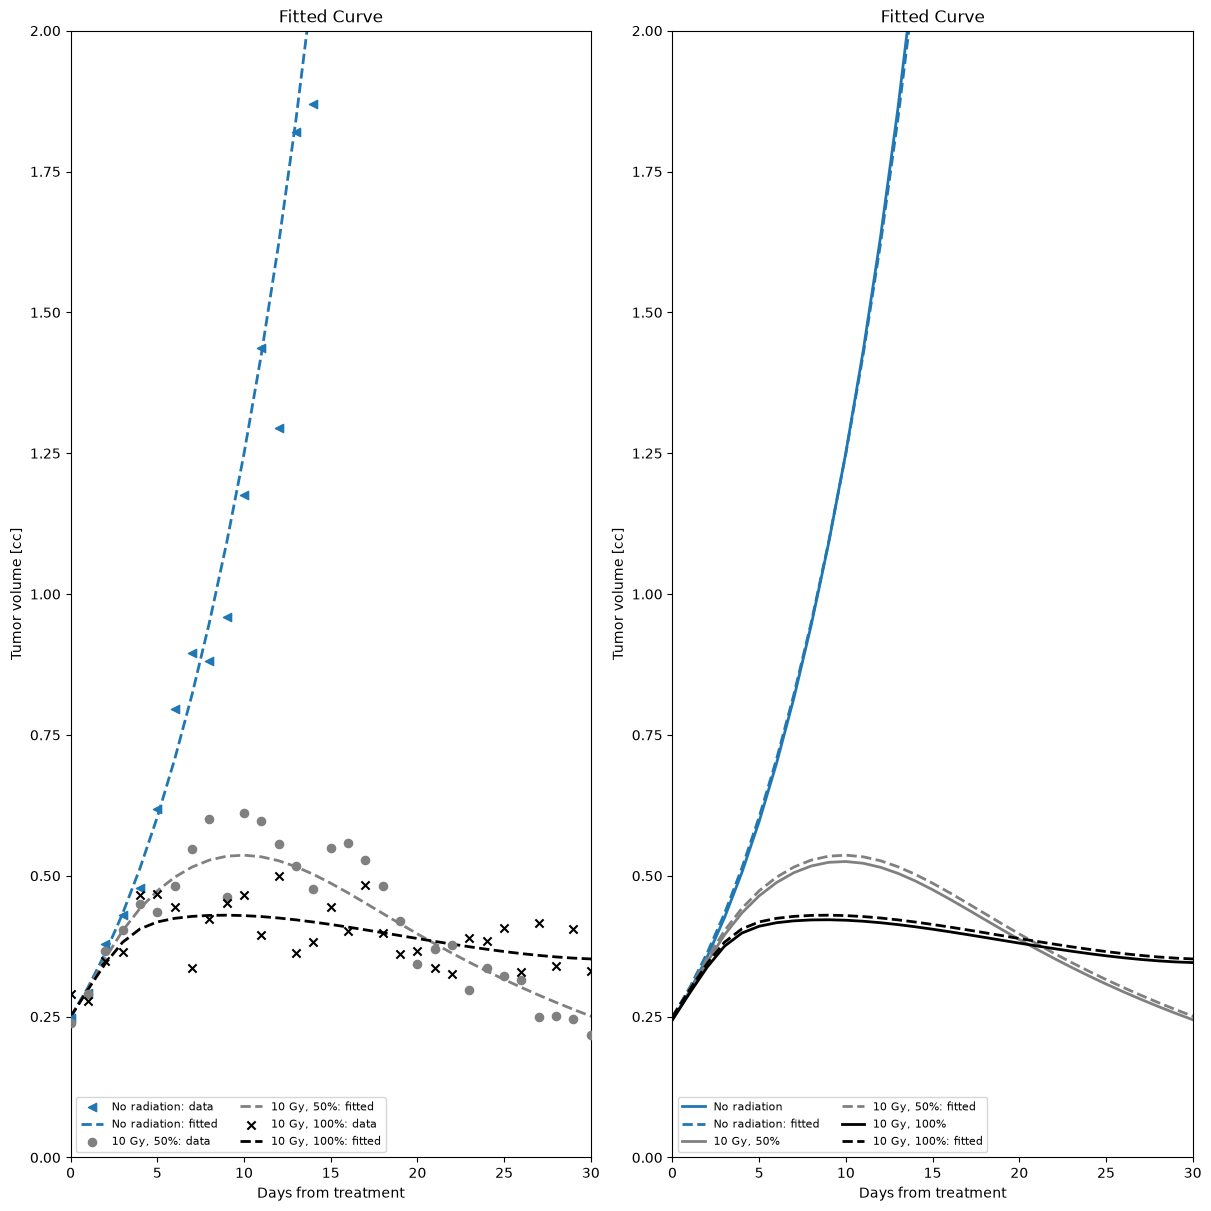

In [15]:
fig, axes = plt.subplots(1,2,figsize=(12, 12),constrained_layout=True)

for arm in DATASET.arms:
    color = ARM_COLORS[arm.name]
    marker = ARM_MARKERS[arm.name]

    fitted_result = simulate(
        FIT_RESULT.params,
        arm.coverage,
    )
    fitted_curve = fitted_result.total_volume[
        TRUE_PARAMS.treatment_day:
    ]
    fitted_days = np.arange(len(fitted_curve))

    axes[0].scatter(
        arm.relative_days,
        arm.observed_volume,
        color=color,
        marker=marker,
        s=35,
        label=f"{arm.name}: data",
        zorder=3,
    )
    axes[0].plot(
        fitted_days,
        fitted_curve,
        color=color,
        lw=2,
        ls="--",
        label=f"{arm.name}: fitted",
    )

    axes[1].plot(
        arm.relative_days,
        arm.clean_volume,
        color=color,
        linewidth=2,
        label=arm.name,
    )
    axes[1].plot(
        fitted_days,
        fitted_curve,
        color=color,
        lw=2,
        ls="--",
        label=f"{arm.name}: fitted",
    )


axes[0].set(
    xlim=(0, 30),
    # yscale="log",
    ylim=(0,2),
    xlabel="Days from treatment",
    ylabel="Tumor volume [cc]",
    title="Fitted Curve",
)
axes[1].set(
    xlim=(0, 30),
    # yscale="log",
    ylim=(0,2),
    xlabel="Days from treatment",
    ylabel="Tumor volume [cc]",
    title="Fitted Curve",
)

axes[0].legend(fontsize=8, ncol=2)
axes[1].legend(fontsize=8, ncol=2)


plt.show()


## Fitting parameters
$$
\boxed{\theta=(\mu,\omega,\psi,\kappa)}
\tag{14}
$$


- $\mu$: tumor growth rate
- $\omega$: CTL-to-killing efficiency
- $\psi$: radiation-induced infiltration/activation
- $\kappa$: immune suppression

$$
\rho,\;
\alpha_T,\beta_T,\alpha_L,\beta_L,\;
\lambda_T,\lambda_L,\lambda_A,\;
\gamma,r,s,\;
d_{\mathrm{RT}},t_{\mathrm{RT}}.
$$


$$
-\log S_{10}=10\alpha+100\beta
\tag{15}
$$



## Real data?

| arm | coverage | dose_gy | treatment_day | day_from_treatment | volume_cc | log_sigma |
|---|---:|---:|---:|---:|---:|---:|
| No radiation | 0.0 | 0 | 10 | 0 | ... | ... |
| No radiation | 0.0 | 0 | 10 | 3 | ... | ... |
| 10 Gy, 50% | 0.5 | 10 | 10 | 0 | ... | ... |
| 10 Gy, 100% | 1.0 | 10 | 10 | 0 | ... | ... |
